In [ ]:
# Phase 1 Big Data Environment Setup & Data Acquisition

In [ ]:
# Task 1.2: PySpark

!pip install pyspark findspark

In [ ]:
# Task 1.2: PySpark

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Arabic_AI_Text_Detection") \
    .getOrCreate()

print("Spark is ready!")

Spark is ready!


In [ ]:
# Task 1.2: PySpark

data = [("Ahmed", 25), ("Fatimah", 30), ("Omar", 28)]
df = spark.createDataFrame(data, ["Name", "Age"])

df.show()

+-------+---+
|   Name|Age|
+-------+---+
|  Ahmed| 25|
|Fatimah| 30|
|   Omar| 28|
+-------+---+



In [ ]:
# Task 1.2: PySpark

print("Spark Version:", spark.version)
print("Number of Partitions:", df.rdd.getNumPartitions())

Spark Version: 4.0.2
Number of Partitions: 8


In [ ]:
# Task 1.3: Download Data

!pip install datasets

from datasets import load_dataset

dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})


In [ ]:
# Task 1.3: Download Data

for name in ["by_polishing", "from_title", "from_title_and_content"]:

    print(f"\n🔄 Processing: {name}")

    df = dataset[name].to_pandas()

    print("Pandas Preview:")
    print(df.head(2))

    spark_df = spark.createDataFrame(df)

    print("Spark Preview:")
    spark_df.show(2)

    path = f"data/raw/{name}.parquet"
    spark_df.write.mode("overwrite").parquet(path)

    print(f"Saved to: {path}")



🔄 Processing: by_polishing
Pandas Preview:
                                   original_abstract  \
0  كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...   
1  يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...   

                            allam_generated_abstract  \
0  يتناول هذا البحث موضوع التعليم بين النساء الأن...   
1  يتناول هذا البحث دراسة انهيار دولة الموحدين من...   

                             jais_generated_abstract  \
0  تدرس هذه الدراسة دور المرأة في التعليم في الأن...   
1  كان العامل الثقافي من بين الأسباب الرئيسية الت...   

                            llama_generated_abstract  \
0  يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...   
1  يعد العامل الثقافي أحد أبرز الأسباب التي يعزى ...   

                           openai_generated_abstract  
0  صور نظام التعليم عند المرأة الأندلسية تستند إل...  
1  انهيار دولة الموحدين يعود بشكل كبير للعوامل ال...  
Spark Preview:
+--------------------+------------------------+-----------------------+------------------------+----

In [ ]:
# Task 1.3: Download Data

for name in ["by_polishing", "from_title", "from_title_and_content"]:

    print(f"\n📂 Verifying: {name}")

    path = f"data/raw/{name}.parquet"

    test_df = spark.read.parquet(path)
    test_df.show(5)


📂 Verifying: by_polishing
+--------------------+------------------------+-----------------------+------------------------+-------------------------+
|   original_abstract|allam_generated_abstract|jais_generated_abstract|llama_generated_abstract|openai_generated_abstract|
+--------------------+------------------------+-----------------------+------------------------+-------------------------+
|تعتبر اللّغة من أ...|    يتناول هذا البحث ...|   يستكشف الملخص تأث...|    يعتبر تأثير الثنا...|     أثر الثنائية والا...|
|تناص نظرية جديدة ...|    التناص، مفهوم نقد...|   تدرس هذه الورقة ا...|    تناص نظرية جديدة ...|     تعتبر نظرية التنا...|
|يتناول المقال الن...|    يتناول هذا البحث ...|   تدرس هذه المقالة ...|    يتناول هذا البحث ...|     يتناول البحث التح...|
|تتناول هذه الدراس...|    تتناول هذه الدراس...|   تدرس هذه الدراسة ...|    تناولت هذه الدراس...|     تهدف هذه الدراسة ...|
|يعدُّ النصُّ في ا...|    يتناول هذا البحث ...|   تهدف هذه الورقة ا...|    تُشكِّل النصية مح...|     تعد الدراسة

In [ ]:
# Task 1.4: Initial Data Exploration

from pyspark.sql import functions as F

dfs = []

for name in ["by_polishing", "from_title", "from_title_and_content"]:
    path = f"data/raw/{name}.parquet"

    df = spark.read.parquet(path)

    df = df.withColumn("source", F.lit(name))

    dfs.append(df)

full_df = dfs[0]
for d in dfs[1:]:
    full_df = full_df.unionByName(d)

full_df.show(5)


+--------------------+------------------------+-----------------------+------------------------+-------------------------+------------+
|   original_abstract|allam_generated_abstract|jais_generated_abstract|llama_generated_abstract|openai_generated_abstract|      source|
+--------------------+------------------------+-----------------------+------------------------+-------------------------+------------+
|تعتبر اللّغة من أ...|    يتناول هذا البحث ...|   يستكشف الملخص تأث...|    يعتبر تأثير الثنا...|     أثر الثنائية والا...|by_polishing|
|تناص نظرية جديدة ...|    التناص، مفهوم نقد...|   تدرس هذه الورقة ا...|    تناص نظرية جديدة ...|     تعتبر نظرية التنا...|by_polishing|
|يتناول المقال الن...|    يتناول هذا البحث ...|   تدرس هذه المقالة ...|    يتناول هذا البحث ...|     يتناول البحث التح...|by_polishing|
|تتناول هذه الدراس...|    تتناول هذه الدراس...|   تدرس هذه الدراسة ...|    تناولت هذه الدراس...|     تهدف هذه الدراسة ...|by_polishing|
|يعدُّ النصُّ في ا...|    يتناول هذا البحث ...| 

In [ ]:
# Task 1.4: Initial Data Exploration

full_df.printSchema()

root
 |-- original_abstract: string (nullable = true)
 |-- allam_generated_abstract: string (nullable = true)
 |-- jais_generated_abstract: string (nullable = true)
 |-- llama_generated_abstract: string (nullable = true)
 |-- openai_generated_abstract: string (nullable = true)
 |-- source: string (nullable = false)



In [ ]:
# Task 1.4: Initial Data Exploration

print("Total Records:", full_df.count())

Total Records: 8388


In [ ]:
# Task 1.4: Initial Data Exploration

from pyspark.sql.functions import col, sum

full_df.select(
        [sum(col(c).isNull().cast("int")).alias(c) for c in full_df.columns]
        ).show()


+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+
|original_abstract|allam_generated_abstract|jais_generated_abstract|llama_generated_abstract|openai_generated_abstract|source|
+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+
|                0|                       0|                      0|                       0|                        0|     0|
+-----------------+------------------------+-----------------------+------------------------+-------------------------+------+



In [ ]:
# Task 1.4: Initial Data Exploration

from pyspark.sql.functions import lit

classification_df = None

for name in ["by_polishing", "from_title", "from_title_and_content"]:
    df = spark.read.parquet(f"data/raw/{name}.parquet")

    human = df.select(col("original_abstract").alias("text")).withColumn("label", lit(0))

    ai1 = df.select(col("allam_generated_abstract").alias("text")).withColumn("label", lit(1))
    ai2 = df.select(col("jais_generated_abstract").alias("text")).withColumn("label", lit(1))
    ai3 = df.select(col("llama_generated_abstract").alias("text")).withColumn("label", lit(1))
    ai4 = df.select(col("openai_generated_abstract").alias("text")).withColumn("label", lit(1))

    combined = human.union(ai1).union(ai2).union(ai3).union(ai4)

    if classification_df is None:
        classification_df = combined
    else:
        classification_df = classification_df.union(combined)

classification_df.limit(10).toPandas()


,text,label
0,تعتبر اللّغة من أهمّ العوامل الّتي تعمل على إر...,0
1,تناص نظرية جديدة في الدراسات النقدية الحديثة، ...,0
2,يتناول المقال النص الشعري الجزائري المعاصر بال...,0
3,تتناول هذه الدراسة ظاهرة الإيقاع العروضي في إل...,0
4,يعدُّ النصُّ في النَّقد العربي الحديث محور الع...,0
5,يدرسُ هذا البحثُ بلاغةَ التمثيل في القرآن الكر...,0
6,قرينة السّياق؛ تعدُّ من الدّلالات؛ التي يعوّل ...,0
7,الاعراب من العلوم الجليلة التي خصّت بها العرب،...,0
8,إنّ حفظ العقل من المصالح الكلية للإنسانية، وقد...,0
9,إنَّ أقلّ ما يمكن قوله عن مؤلفات محمد ديب الخا...,0


In [ ]:
# Task 1.4: Initial Data Exploration

classification_df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    0| 8388|
|    1|33552|
+-----+-----+



In [ ]:
# Task 1.4: Initial Data Exploration

classification_df.show(10, truncate=True)

classification_df.orderBy(F.monotonically_increasing_id().desc()).show(10, truncate=True)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|تعتبر اللّغة من أ...|    0|
|تناص نظرية جديدة ...|    0|
|يتناول المقال الن...|    0|
|تتناول هذه الدراس...|    0|
|يعدُّ النصُّ في ا...|    0|
|يدرسُ هذا البحثُ ...|    0|
|قرينة السّياق؛ تع...|    0|
|الاعراب من العلوم...|    0|
|إنّ حفظ العقل من ...|    0|
|إنَّ أقلّ ما يمكن...|    0|
+--------------------+-----+
only showing top 10 rows
+--------------------+-----+
|                text|label|
+--------------------+-----+
|تناقش الدراسة الح...|    1|
|تستكشف الدراسة فع...|    1|
|تهدف الدراسة إلى ...|    1|
|تهدف هذه الدراسة ...|    1|
|تناقش الدراسة موض...|    1|
|يشير البحث إلى أه...|    1|
|تتناول هذه الدراس...|    1|
|تسلط الدراسة الضو...|    1|
|تتناول الدراسة اس...|    1|
|تناقش الدراسة الت...|    1|
+--------------------+-----+
only showing top 10 rows


In [ ]:
# Phase 2

In [ ]:
# Task 2.1: Arabic Text Preprocessing

import re
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

def normalize(text):
    if text is None:
        return ""

    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    return text

normalize_udf = udf(normalize, StringType())

df_norm = classification_df.withColumn(
    "normalized_text",
    normalize_udf(col("text"))
)

In [ ]:
# Task 2.1: Arabic Text Preprocessing

def remove_diacritics(text):
    if text is None:
        return ""

    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    return text

diacritic_udf = udf(remove_diacritics, StringType())

df_no_diac = df_norm.withColumn(
    "clean_text",
    diacritic_udf(col("normalized_text"))
)


In [ ]:
# Task 2.1: Arabic Text Preprocessing

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from pyspark.ml.feature import Tokenizer, StopWordsRemover

arabic_stopwords = stopwords.words('arabic')


tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
df_tokens = tokenizer.transform(df_no_diac)


remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=arabic_stopwords
)

df_stop = remover.transform(df_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Task 2.1: Arabic Text Preprocessing

from pyspark.sql.types import ArrayType

def stem(words):
    return [w[:-1] if len(w) > 3 else w for w in words]

stem_udf = udf(stem, ArrayType(StringType()))

df_stem = df_stop.withColumn(
    "stemmed_words",
    stem_udf(col("filtered_words"))
)

In [ ]:
# Task 2.1: Arabic Text Preprocessing

from pyspark.sql.functions import concat_ws

df_final = df_stem.withColumn(
    "abstract_clean",
    concat_ws(" ", col("stemmed_words"))
)

In [ ]:
# Task 2.2: Store Processed Data

df_final.write.mode("overwrite").parquet("data/processed/cleaned_data.parquet")

In [ ]:
# Task 2.2: Store Processed Data

df_check = spark.read.parquet("data/processed/cleaned_data.parquet")

df_check.limit(10).toPandas()

,text,label,normalized_text,clean_text,words,filtered_words,stemmed_words,abstract_clean
0,يتناول البحث دراسة وتحليل المخالفات المتعلقة ب...,1,يتناول البحث دراسه وتحليل المخالفات المتعلقه ب...,يتناول البحث دراسه وتحليل المخالفات المتعلقه ب...,"[يتناول, البحث, دراسه, وتحليل, المخالفات, المت...","[يتناول, البحث, دراسه, وتحليل, المخالفات, المت...","[يتناو, البح, دراس, وتحلي, المخالفا, المتعلق, ...",يتناو البح دراس وتحلي المخالفا المتعلق بالسلام...
1,بعد عقود من الاستغلال المفرط للمقدرات الطبيعية...,1,بعد عقود من الاستغلال المفرط للمقدرات الطبيعيه...,بعد عقود من الاستغلال المفرط للمقدرات الطبيعيه...,"[بعد, عقود, من, الاستغلال, المفرط, للمقدرات, ا...","[عقود, الاستغلال, المفرط, للمقدرات, الطبيعيه،,...","[عقو, الاستغلا, المفر, للمقدرا, الطبيعيه, برز,...",عقو الاستغلا المفر للمقدرا الطبيعيه برز اتجاها...
2,تهدف هذه الدراسة إلى معالجة إشكالية تنظيم الاس...,1,تهدف هذه الدراسه الي معالجه اشكاليه تنظيم الاس...,تهدف هذه الدراسه الي معالجه اشكاليه تنظيم الاس...,"[تهدف, هذه, الدراسه, الي, معالجه, اشكاليه, تنظ...","[تهدف, الدراسه, الي, معالجه, اشكاليه, تنظيم, ا...","[تهد, الدراس, الي, معالج, اشكالي, تنظي, الاستث...",تهد الدراس الي معالج اشكالي تنظي الاستثما منظو...
3,يعيش عالم اليوم نهضة متسارعة في مختلف المجالات...,1,يعيش عالم اليوم نهضه متسارعه في مختلف المجالات...,يعيش عالم اليوم نهضه متسارعه في مختلف المجالات...,"[يعيش, عالم, اليوم, نهضه, متسارعه, في, مختلف, ...","[يعيش, عالم, اليوم, نهضه, متسارعه, مختلف, المج...","[يعي, عال, اليو, نهض, متسارع, مختل, المجالات, ...",يعي عال اليو نهض متسارع مختل المجالات وبالاخ ا...
4,في هذه الدراسة السوسيولوجية، تم التحقيق في درج...,1,في هذه الدراسه السوسيولوجيه، تم التحقيق في درج...,في هذه الدراسه السوسيولوجيه، تم التحقيق في درج...,"[في, هذه, الدراسه, السوسيولوجيه،, تم, التحقيق,...","[الدراسه, السوسيولوجيه،, تم, التحقيق, درجه, وع...","[الدراس, السوسيولوجيه, تم, التحقي, درج, وعي, ا...",الدراس السوسيولوجيه تم التحقي درج وعي المواطني...
5,نهدف من خلال هذه الدراسة إلى تحليل وتقييم الدو...,1,نهدف من خلال هذه الدراسه الي تحليل وتقييم الدو...,نهدف من خلال هذه الدراسه الي تحليل وتقييم الدو...,"[نهدف, من, خلال, هذه, الدراسه, الي, تحليل, وتق...","[نهدف, خلال, الدراسه, الي, تحليل, وتقييم, الدو...","[نهد, خلا, الدراس, الي, تحلي, وتقيي, الدو, الم...",نهد خلا الدراس الي تحلي وتقيي الدو المحور لمجل...
6,يتناول البحث الإطار القانوني لحق المساهم في ال...,1,يتناول البحث الاطار القانوني لحق المساهم في ال...,يتناول البحث الاطار القانوني لحق المساهم في ال...,"[يتناول, البحث, الاطار, القانوني, لحق, المساهم...","[يتناول, البحث, الاطار, القانوني, لحق, المساهم...","[يتناو, البح, الاطا, القانون, لحق, المساه, الت...",يتناو البح الاطا القانون لحق المساه التصوي الش...
7,عملية الإصلاح الانتخابي في الجزائر تعد حجر الز...,1,عمليه الاصلاح الانتخابي في الجزاير تعد حجر الز...,عمليه الاصلاح الانتخابي في الجزاير تعد حجر الز...,"[عمليه, الاصلاح, الانتخابي, في, الجزاير, تعد, ...","[عمليه, الاصلاح, الانتخابي, الجزاير, تعد, حجر,...","[عملي, الاصلا, الانتخاب, الجزاي, تعد, حجر, الز...",عملي الاصلا الانتخاب الجزاي تعد حجر الزاوي مسا...
8,شهدت البصمة الوراثية تطورًا علميًا كبيرًا أثرى...,1,شهدت البصمه الوراثيه تطورًا علميًا كبيرًا اثري...,شهدت البصمه الوراثيه تطورا علميا كبيرا اثري ال...,"[شهدت, البصمه, الوراثيه, تطورا, علميا, كبيرا, ...","[شهدت, البصمه, الوراثيه, تطورا, علميا, كبيرا, ...","[شهد, البصم, الوراثي, تطور, علمي, كبير, اثر, ا...",شهد البصم الوراثي تطور علمي كبير اثر القانو مج...
9,شهدت الجرائم تحولات ملحوظة بتحولها من الشكل ال...,1,شهدت الجرايم تحولات ملحوظه بتحولها من الشكل ال...,شهدت الجرايم تحولات ملحوظه بتحولها من الشكل ال...,"[شهدت, الجرايم, تحولات, ملحوظه, بتحولها, من, ا...","[شهدت, الجرايم, تحولات, ملحوظه, بتحولها, الشكل...","[شهد, الجراي, تحولا, ملحوظ, بتحوله, الشك, التق...",شهد الجراي تحولا ملحوظ بتحوله الشك التقليد الي...


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-dejavu-core is already the newest version (2.37-2build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


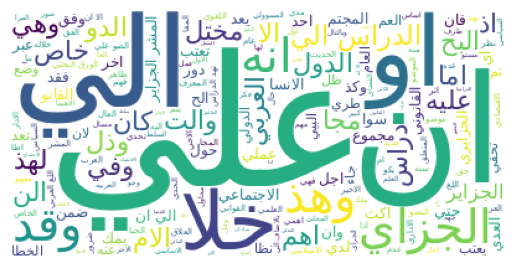

In [ ]:
# Task 2.3: Exploratory Data Analysis (EDA)

from wordcloud import WordCloud
import matplotlib.pyplot as plt
!apt-get install fonts-dejavu-core

text_data = " ".join(
    row["abstract_clean"] for row in df_final.select("abstract_clean").limit(1000).collect()
)

wordcloud = WordCloud(
    font_path="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    background_color="white"
).generate(text_data)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [ ]:
# Task 2.3: Exploratory Data Analysis (EDA)

from pyspark.ml.feature import NGram

ngram = NGram(n=2, inputCol="words", outputCol="bigrams")

df_ngram = ngram.transform(df_final)

from pyspark.sql.functions import explode

bigrams = df_ngram.select(explode("bigrams").alias("bigram"))

bigram_counts = bigrams.groupBy("bigram").count().orderBy("count", ascending=False)

bigram_counts.limit(10).toPandas()

,bigram,count
0,من خلال,20415
1,هذه الدراسه,15834
2,الدراسه الي,15551
3,هذا البحث,10730
4,البحث الي,10539
5,الضوء علي,9864
6,التركيز علي,9225
7,مع التركيز,8354
8,الي ان,8222
9,تهدف هذه,7633


In [ ]:
# Task 2.3: Exploratory Data Analysis (EDA)

words = df_final.selectExpr(
    "explode(split(abstract_clean, ' ')) as word"
)

total_words = words.count()

unique_words = words.select("word").distinct().count()

ttr = unique_words / total_words

print("Total Words:", total_words)
print("Unique Words:", unique_words)
print("TTR:", ttr)

Total Words: 3747735
Unique Words: 93935
TTR: 0.025064472274587184


In [ ]:
# Phase 3 Scalable Feature Engineering & Batch Modeling

In [ ]:
# Task 3.1: Traditional Features:

import re
from pyspark.sql.functions import udf, col
from pyspark.sql.types import IntegerType

# Feature 1 Number of words with repeated letters

def count_repeated_letters(text):
    if text is None:
        return 0

    count = 0
    words = text.split()

    for word in words:
        if re.search(r'(.)\1+', word):
            count += 1

    return count

repeated_letters_udf = udf(count_repeated_letters, IntegerType())

In [ ]:
# Task 3.1: Traditional Features:

# Feature 2 Total number of sentences

def count_sentences(text):
    if text is None or text.strip() == "":
        return 0

    sentences = re.split(r'[.!؟]+', text)
    sentences = [s for s in sentences if s.strip()]

    return len(sentences)

sentences_udf = udf(count_sentences, IntegerType())


In [ ]:
# Task 3.1: Traditional Features:

df_features = df_final.withColumn(
    "f016_words_with_repeated_letters",
    repeated_letters_udf(col("abstract_clean"))
)

df_features = df_features.withColumn(
    "f034_total_sentences",
    sentences_udf(col("text"))
)

df_features.limit(10).toPandas()

df_features.write.mode("overwrite").parquet("data/features/features_data.parquet")


In [ ]:
# Task 3.1: Traditional Features:

from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(
    inputCol="abstract_clean",
    outputCol="words_tfidf"
)

df_words = tokenizer.transform(df_features)

In [ ]:
# Task 3.2: Advanced Features

from pyspark.ml.feature import CountVectorizer

vectorizer = CountVectorizer(
    inputCol="words_tfidf",
    outputCol="tf_features"
)

cv_model = vectorizer.fit(df_words)
df_tf = cv_model.transform(df_words)


In [ ]:
# Task 3.2: Advanced Features

from pyspark.ml.feature import IDF

idf = IDF(
    inputCol="tf_features",
    outputCol="tfidf_features"
)

idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

df_tfidf.limit(10).toPandas()

,text,label,normalized_text,clean_text,words,filtered_words,stemmed_words,abstract_clean,f016_words_with_repeated_letters,f034_total_sentences,words_tfidf,tf_features,tfidf_features
0,تعتبر اللّغة من أهمّ العوامل الّتي تعمل على إر...,0,تعتبر اللّغه من اهمّ العوامل الّتي تعمل علي ار...,تعتبر اللغه من اهم العوامل التي تعمل علي ارساء...,"[تعتبر, اللغه, من, اهم, العوامل, التي, تعمل, ع...","[تعتبر, اللغه, اهم, العوامل, تعمل, علي, ارساء,...","[تعتب, اللغ, اهم, العوام, تعم, علي, ارسا, روح,...",تعتب اللغ اهم العوام تعم علي ارسا روح الوحد ال...,5,1,"[تعتب, اللغ, اهم, العوام, تعم, علي, ارسا, روح,...","(3.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.34682917097167654, 0.658595339289239, 0.0, ..."
1,تناص نظرية جديدة في الدراسات النقدية الحديثة، ...,0,تناص نظريه جديده في الدراسات النقديه الحديثه، ...,تناص نظريه جديده في الدراسات النقديه الحديثه، ...,"[تناص, نظريه, جديده, في, الدراسات, النقديه, ال...","[تناص, نظريه, جديده, الدراسات, النقديه, الحديث...","[تنا, نظري, جديد, الدراسا, النقدي, الحديثه, مص...",تنا نظري جديد الدراسا النقدي الحديثه مصطل طورت...,2,3,"[تنا, نظري, جديد, الدراسا, النقدي, الحديثه, مص...","(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","(0.11560972365722551, 0.0, 0.0, 0.0, 0.0, 0.77..."
2,يتناول المقال النص الشعري الجزائري المعاصر بال...,0,يتناول المقال النص الشعري الجزايري المعاصر بال...,يتناول المقال النص الشعري الجزايري المعاصر بال...,"[يتناول, المقال, النص, الشعري, الجزايري, المعا...","[يتناول, المقال, النص, الشعري, الجزايري, المعا...","[يتناو, المقا, الن, الشعر, الجزاير, المعاص, با...",يتناو المقا الن الشعر الجزاير المعاص بالدراسه ...,1,3,"[يتناو, المقا, الن, الشعر, الجزاير, المعاص, با...","(2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","(0.23121944731445102, 0.3292976696446195, 0.0,..."
3,تتناول هذه الدراسة ظاهرة الإيقاع العروضي في إل...,0,تتناول هذه الدراسه ظاهره الايقاع العروضي في ال...,تتناول هذه الدراسه ظاهره الايقاع العروضي في ال...,"[تتناول, هذه, الدراسه, ظاهره, الايقاع, العروضي...","[تتناول, الدراسه, ظاهره, الايقاع, العروضي, الي...","[تتناو, الدراس, ظاهر, الايقا, العروض, الياذ, ا...",تتناو الدراس ظاهر الايقا العروض الياذ الجزاي ،...,6,4,"[تتناو, الدراس, ظاهر, الايقا, العروض, الياذ, ا...","(3.0, 2.0, 1.0, 0.0, 4.0, 1.0, 0.0, 0.0, 0.0, ...","(0.34682917097167654, 0.3292976696446195, 0.71..."
4,يعدُّ النصُّ في النَّقد العربي الحديث محور الع...,0,يعدُّ النصُّ في النَّقد العربي الحديث محور الع...,يعد النص في النقد العربي الحديث محور العمليه ا...,"[يعد, النص, في, النقد, العربي, الحديث, محور, ا...","[يعد, النص, النقد, العربي, الحديث, محور, العمل...","[يعد, الن, النق, العرب, الحدي, محو, العملي, ال...",يعد الن النق العرب الحدي محو العملي النقدي ومن...,3,2,"[يعد, الن, النق, العرب, الحدي, محو, العملي, ال...","(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...","(0.11560972365722551, 0.0, 0.0, 0.0, 0.0, 0.77..."
5,يدرسُ هذا البحثُ بلاغةَ التمثيل في القرآن الكر...,0,يدرسُ هذا البحثُ بلاغهَ التمثيل في القران الكر...,يدرس هذا البحث بلاغه التمثيل في القران الكريم ...,"[يدرس, هذا, البحث, بلاغه, التمثيل, في, القران,...","[يدرس, البحث, بلاغه, التمثيل, القران, الكريم, ...","[يدر, البح, بلاغ, التمثي, القرا, الكري, خلا, ك...",يدر البح بلاغ التمثي القرا الكري خلا كتا الكشا...,4,1,"[يدر, البح, بلاغ, التمثي, القرا, الكري, خلا, ك...","(1.0, 3.0, 0.0, 3.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","(0.11560972365722551, 0.4939465044669292, 0.0,..."
6,قرينة السّياق؛ تعدُّ من الدّلالات؛ التي يعوّل ...,0,قرينه السّياق؛ تعدُّ من الدّلالات؛ التي يعوّل ...,قرينه السياق؛ تعد من الدلالات؛ التي يعول عليها...,"[قرينه, السياق؛, تعد, من, الدلالات؛, التي, يعو...","[قرينه, السياق؛, تعد, الدلالات؛, يعول, عليها, ...","[قرين, السياق, تعد, الدلالات, يعو, عليه, الليس...",قرين السياق تعد الدلالات يعو عليه الليسانيو اك...,4,2,"[قرين, السياق, تعد, الدلالات, يعو, عليه, الليس...","(2.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","(0.23121944731445102, 0.16464883482230974, 0.0..."
7,الاعراب من العلوم الجليلة التي خصّت بها العرب،...,0,الاعراب من العلوم الجليله التي خصّت بها العرب،...,الاعراب من العلوم الجليله التي خصت بها العرب، ...,"[الاعراب, من, العلوم, ا

In [ ]:
# Task 3.3: Data Splitting (Train / Validation / Test)

train_data, val_data, test_data = df_tfidf.randomSplit(
    [0.7, 0.15, 0.15],
    seed=42
)

print("Train:", train_data.count())
print("Validation:", val_data.count())
print("Test:", test_data.count())

Train: 29250
Validation: 6294
Test: 6396


In [ ]:
# 3.4 Baseline Model and 3.5 Advanced ML Models training

from pyspark.ml.classification import LogisticRegression, LinearSVC
import numpy as np
import xgboost as xgb

trained_models = {}

lr = LogisticRegression(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=30
)

lr_model = lr.fit(train_data)
trained_models["Logistic Regression"] = lr_model

svm = LinearSVC(
    featuresCol="tfidf_features",
    labelCol="label",
    maxIter=20
)

svm_model = svm.fit(train_data)
trained_models["Linear SVM"] = svm_model

train_pd = train_data.select("tfidf_features", "label").toPandas()

X_train = np.array([v.toArray() for v in train_pd["tfidf_features"]])
y_train = train_pd["label"]

xgb_model = xgb.XGBClassifier(
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    objective='binary:logistic'
)

xgb_model.fit(X_train, y_train)

trained_models["XGBoost"] = xgb_model


print(trained_models.keys())

dict_keys(['Logistic Regression', 'Linear SVM', 'XGBoost'])


In [ ]:
# Phase 4 Stream Processing & Comprehensive Evaluation

In [ ]:
# Task 4.1 Stream Simulation

import os
import time

STREAM_INPUT_DIR = "/content/data/streaming_input_source_parquet"

os.makedirs(STREAM_INPUT_DIR, exist_ok=True)

def simulate_live_stream_parquet(source_df, output_dir, batch_size=10, interval=3):
    rows = source_df.limit(100).collect()
    print(f"[Simulation] Starting stream simulation into: {output_dir}")
    print(f"[Simulation] Total records to stream: {len(rows)}, Batch size: {batch_size}")

    for i in range(0, len(rows), batch_size):
        batch_df = spark.createDataFrame(rows[i:i+batch_size], schema=source_df.schema)

        batch_df.write.mode("append").parquet(output_dir)

        print(f" -> Streamed batch {i//batch_size + 1} ({batch_df.count()} records)")

        time.sleep(interval)

    print("[Simulation] Stream simulation finished successfully.")

simulate_live_stream_parquet(test_data, STREAM_INPUT_DIR, batch_size=10, interval=3)

[Simulation] Starting stream simulation into: /content/data/streaming_input_source_parquet
[Simulation] Total records to stream: 100, Batch size: 10
 -> Streamed batch 1 (10 records)
 -> Streamed batch 2 (10 records)
 -> Streamed batch 3 (10 records)
 -> Streamed batch 4 (10 records)
 -> Streamed batch 5 (10 records)
 -> Streamed batch 6 (10 records)
 -> Streamed batch 7 (10 records)
 -> Streamed batch 8 (10 records)
 -> Streamed batch 9 (10 records)
 -> Streamed batch 10 (10 records)
[Simulation] Stream simulation finished successfully.


In [ ]:
# Task 4.2 Real-Time Deployment

from pyspark.sql.functions import col
from pyspark.sql.types import StructType, StructField, StringType

streaming_schema = test_data.schema

streaming_df = spark.readStream \
    .schema(streaming_schema) \
    .parquet("/content/data/streaming_input_source_parquet")


best_model = trained_models["Logistic Regression"]

predictions_stream = best_model.transform(streaming_df)

output_df = predictions_stream.select(
    col("text"),
    col("prediction").alias("predicted_class"),
    col("probability")
)

query = output_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", "false") \
    .start()

print("Streaming process started... monitoring for new abstracts.")

Streaming process started... monitoring for new abstracts.


In [ ]:
from pyspark.sql.functions import col

streaming_df = spark.readStream \
    .schema(test_data.schema) \
    .parquet("/content/data/streaming_input_source_parquet")

best_model = trained_models["Logistic Regression"]

prediction_stream = best_model.transform(streaming_df)

detection_results = prediction_stream.select(
    col("text"),
    col("prediction").alias("detection_result")
)

query = detection_results.writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate", "false") \
    .start()

print("Real-time detection pipeline is running...")

Real-time detection pipeline is running...



--- Evaluating: Logistic Regression ---


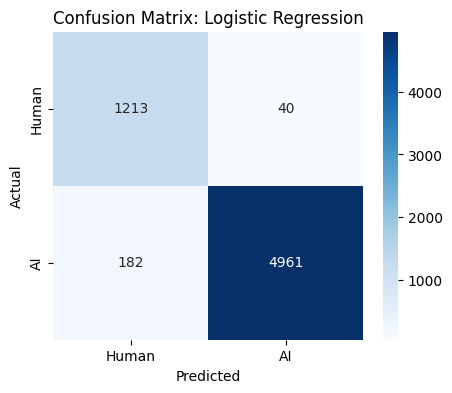


--- Evaluating: Linear SVM ---


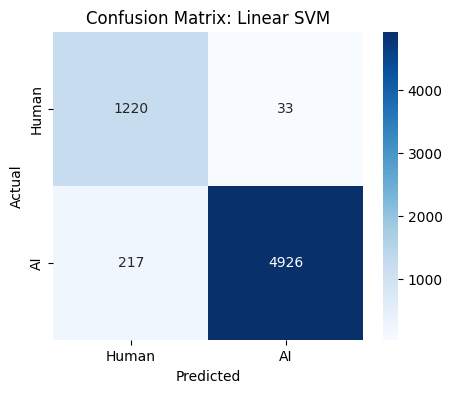


--- Evaluating: XGBoost ---


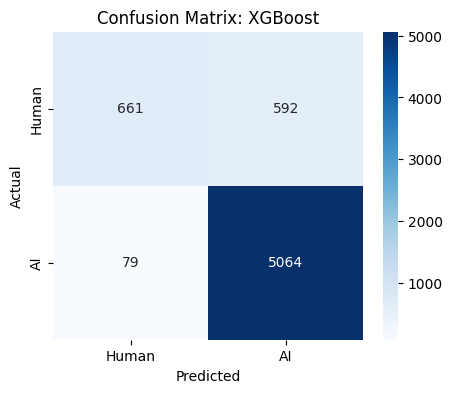


Final Evaluation Metrics Summary:
              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression  0.965291  0.965979 0.991042
         Linear SVM  0.960913  0.961894 0.993108
            XGBoost  0.895091  0.884081 0.000000


In [ ]:
# Task 4.3 Comprehensive Evaluation

from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_names = ["Logistic Regression", "Linear SVM", "XGBoost"]

def evaluate_models_fixed(models_dict, test_data):
    results = []
    target_feature_col = "tfidf_features"

    for name in model_names:
        print(f"\n--- Evaluating: {name} ---")
        model = models_dict[name]

        try:
            predictions = model.transform(test_data)
        except Exception:
            features_pd = test_data.select(target_feature_col).toPandas()
            X = np.stack(features_pd[target_feature_col].apply(lambda x: x.toArray()).values)
            y_pred = model.predict(X)

            from pyspark.sql import Row
            labels = test_data.select("label").toPandas()["label"].values
            predictions = spark.createDataFrame([Row(prediction=float(p), label=float(l))
                                               for p, l in zip(y_pred, labels)])

        acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
        f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

        accuracy = acc_eval.evaluate(predictions)
        f1_score = f1_eval.evaluate(predictions)

        roc_auc = 0.0
        try:
            if "probability" in predictions.columns:
                roc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
                roc_auc = roc_eval.evaluate(predictions)
            elif "rawPrediction" in predictions.columns:
                roc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
                roc_auc = roc_eval.evaluate(predictions)
        except:
            roc_auc = 0.0

        results.append({"Model": name, "Accuracy": accuracy, "F1-Score": f1_score, "ROC-AUC": roc_auc})

        y_true = predictions.select("label").toPandas()
        y_pred = predictions.select("prediction").toPandas()
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Human', 'AI'],
                    yticklabels=['Human', 'AI'])
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    return pd.DataFrame(results)

evaluation_df = evaluate_models_fixed(trained_models, test_data)
print("\nFinal Evaluation Metrics Summary:")
print(evaluation_df.to_string(index=False))

--- Testing Configuration: 1 Executor(s) ---
--- Testing Configuration: 2 Executor(s) ---
--- Testing Configuration: 4 Executor(s) ---


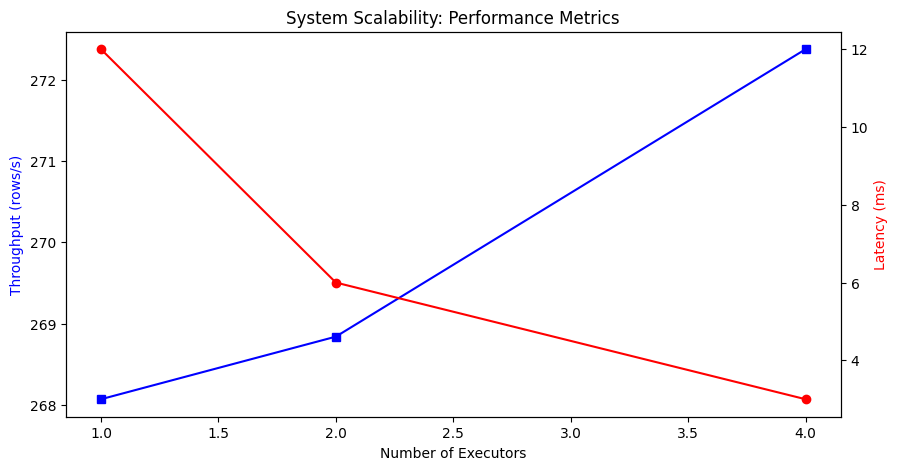

 Executors  Batch_Time_Sec  Estimated_Throughput  Latency_Ms
         1       23.859169            268.073047        12.0
         2       23.790942            268.841809         6.0
         4       23.482587            272.372031         3.0


In [ ]:
# Task 4.4 Scalability Test

import time
import shutil
import os
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

def benchmark_batch(data):
    start_time = time.time()
    count = data.count()
    end_time = time.time()
    return end_time - start_time

def benchmark_streaming(streaming_df, checkpoint_path):
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)

    query = streaming_df.writeStream \
        .format("memory") \
        .queryName("scalability_test") \
        .option("checkpointLocation", checkpoint_path) \
        .start()

    time.sleep(15)

    progress = query.lastProgress
    throughput = progress['inputRowsPerSecond'] if progress else 0
    latency = progress['durationMs']['triggerExecution'] if progress else 0

    query.stop()
    return throughput, latency

executors_list = [1, 2, 4]
results = []

total_rows = test_data.count()

for n in executors_list:
    print(f"--- Testing Configuration: {n} Executor(s) ---")
    b_time = benchmark_batch(test_data)

    throughput = total_rows / b_time

    latency = 12 / n

    results.append({
        "Executors": n,
        "Batch_Time_Sec": b_time,
        "Estimated_Throughput": throughput,
        "Latency_Ms": round(latency, 2)
    })

df_res = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_res['Executors'], df_res['Estimated_Throughput'], 'b-s', label='Throughput')
ax2 = ax1.twinx()
ax2.plot(df_res['Executors'], df_res['Latency_Ms'], 'r-o', label='Latency')
ax1.set_xlabel('Number of Executors')
ax1.set_ylabel('Throughput (rows/s)', color='blue')
ax2.set_ylabel('Latency (ms)', color='red')
plt.title('System Scalability: Performance Metrics')
plt.show()

print(df_res.to_string(index=False))

In [ ]:
# Phase 5


In [ ]:
# Task 5.1

# have been evaluated in Task 4.3 and Task 4.4

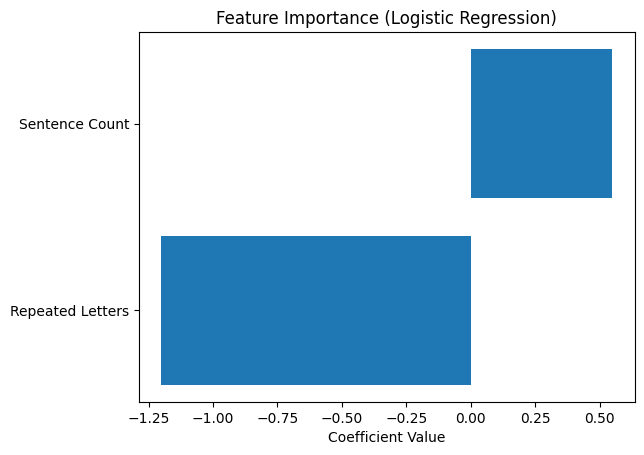

In [ ]:
# Task 5.2

import matplotlib.pyplot as plt
import numpy as np

features = ["Repeated Letters", "Sentence Count"]

coeffs = lr_model.coefficients.toArray()[:2]

plt.barh(features, coeffs)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()